In [1]:
# Importing the required dependencies
import random
import operator
import math
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools

### Helper Functions

In [2]:
# Make a random individual with a variance for each variable.
def generate_individual(size, pos_min, pos_max):
    individual = creator.Individual(random.uniform(pos_min, pos_max) for _ in range(size))
    individual.variance = [random.gauss(0, 1) for _ in range(len(individual))]

    # Do not let the variance get too small.
    individual.variance = [
        max(v, META_EP_EPSILON)
        for v in individual.variance
    ]
    return individual


def mutate_meta_ep(current_individual):
    # Random values used to mutate the solution and variance.
    rx = [random.gauss(0, 1) for _ in range(len(current_individual))]
    rv = [random.gauss(0, 1) for _ in range(len(current_individual))]

    # Change the solution.
    new_individual = creator.Individual(
        list(
            map(
                operator.add,
                current_individual,
                map(
                    operator.mul,
                    rx,
                    map(math.sqrt, current_individual.variance)
                )
            )
        )
    )

    # Change the variance used for the next mutation.
    new_individual.variance = list(
        map(
            operator.add,
            current_individual.variance,
            map(
                operator.mul,
                rv,
                map(
                    math.sqrt,
                    (META_EP_C * v for v in current_individual.variance)
                )
            )
        )
    )

   # Keep the solution within the allowed search domain.
    new_individual[:] = [
        max(POS_MIN, min(POS_MAX, x))
        for x in new_individual
    ]
    
    # Keep the variance above epsilon.
    new_individual.variance = [
        max(v, META_EP_EPSILON)
        for v in new_individual.variance
    ]

    return new_individual


# Fitness functions: Rosenbrock function
def evaluation_rosenbrock(individual):
    fitness = sum(100 * (individual[i] ** 2 - individual[i + 1]) ** 2 + (individual[i] - 1) ** 2 for i in range(len(individual) - 1))
    return (fitness,)

# Fitness functions: Griewank function
def evaluation_griewank(individual):
    sum_part = sum(x ** 2 / 4000 for x in individual)
    product_part = math.prod(math.cos(x / math.sqrt(i + 1)) for i, x in enumerate(individual))
    fitness = sum_part - product_part + 1
    return (fitness,)

### Configuration variables

In [3]:
# Note: Please make a change here if you want to change the number of decision variables.
# Number of variables
NUM_DECISION_VARIABLES = 50

# Population size and number of generations
POPULATION_SIZE = 50
NUM_OF_GEN = 1000

# Search space limits
POS_MIN = -30
POS_MAX = 30

# Note: Make change here if you want to 
# Choose the fitness function here.
EVALUATION_FUNC_NAME = "evaluation_griewank"

EVALUATION_FUNCTIONS = {
    "evaluation_rosenbrock": evaluation_rosenbrock,
    "evaluation_griewank": evaluation_griewank
}

# Meta-EP settings
META_EP_BETA = (POS_MAX - POS_MIN) / 10
META_EP_C = 1
META_EP_EPSILON = META_EP_BETA / 10

### Toolbox

In [4]:
# Set up the fitness and individual classes.
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin, variance=list)

# Set up the toolbox.
toolbox = base.Toolbox()

toolbox.register("individual",
                 generate_individual,
                 size=NUM_DECISION_VARIABLES,
                 pos_min=POS_MIN,
                 pos_max=POS_MAX)

# Create the population.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mutate", mutate_meta_ep)

# Use the Griewank function for fitness.
toolbox.register("evaluate", EVALUATION_FUNCTIONS[EVALUATION_FUNC_NAME])

# Keep the best individuals.
toolbox.register("select", tools.selBest, k=POPULATION_SIZE)

### Meta-EP Algorithm

In [5]:
# Fix the seed so that the evolutionary experiment is reproducible.
seed_list = list(range(1, 31))

results = []

# Stores convergence data for each seed.
convergence_data = {}

for seed in seed_list:
    random.seed(seed)
    
    initial_population = toolbox.population(POPULATION_SIZE)
    
    current_population = initial_population
    
    # Evaluate the population before starting evolutionary selection.
    for individual in current_population:
        individual.fitness.values = toolbox.evaluate(individual)

    # Store the best fitness of the initial population.
    best_fitness_by_generation = [
        toolbox.select(current_population, k=1)[0].fitness.values[0]
    ]
    
    for gen in range(NUM_OF_GEN):
        new_population = []

        for individual in current_population:
            # Create one offspring by mutating the parent's solution and variance.
            new_mutated_individual = toolbox.mutate(individual)
            new_population.append(new_mutated_individual)
    
        # Evaluate the newly generated offspring.
        for individual in new_population:
            individual.fitness.values = toolbox.evaluate(individual)
    
        # Combine parents and offspring for elitist survival selection.
        total_population = current_population + new_population
    
        # Retain the best N individuals for the next generation.
        current_population = toolbox.select(total_population)

        # Record the best fitness of this generation.
        best_fitness_by_generation.append(
            current_population[0].fitness.values[0]
        )

    # Get the best solution from the final population.
    best_individual = toolbox.select(current_population, k=1)[0]

    results.append({
        "seed": seed,
        "best_solution": list(best_individual),
        "fitness": best_individual.fitness.values[0]
    })

    # Store convergence history for this seed.
    convergence_data[seed] = best_fitness_by_generation

    print(
        f"Seed : {seed}, "
        f"function: {EVALUATION_FUNC_NAME}, "
        f"Fitness: {best_individual.fitness.values[0]:.5f}"
    )

Seed : 1, function: evaluation_griewank, Fitness: 1.06150
Seed : 2, function: evaluation_griewank, Fitness: 1.05598
Seed : 3, function: evaluation_griewank, Fitness: 1.03643
Seed : 4, function: evaluation_griewank, Fitness: 1.06038
Seed : 5, function: evaluation_griewank, Fitness: 1.07436
Seed : 6, function: evaluation_griewank, Fitness: 1.05622
Seed : 7, function: evaluation_griewank, Fitness: 1.07186
Seed : 8, function: evaluation_griewank, Fitness: 1.02117
Seed : 9, function: evaluation_griewank, Fitness: 1.05155
Seed : 10, function: evaluation_griewank, Fitness: 1.04453
Seed : 11, function: evaluation_griewank, Fitness: 1.09529
Seed : 12, function: evaluation_griewank, Fitness: 1.07943
Seed : 13, function: evaluation_griewank, Fitness: 1.04628
Seed : 14, function: evaluation_griewank, Fitness: 1.05732
Seed : 15, function: evaluation_griewank, Fitness: 1.07050
Seed : 16, function: evaluation_griewank, Fitness: 1.04387
Seed : 17, function: evaluation_griewank, Fitness: 1.04914
Seed :

### Mean and Std Deviation for Fitness

In [6]:
fitness_values = [result["fitness"] for result in results]

mean_fitness = np.mean(fitness_values)
std_fitness = np.std(fitness_values, ddof=1)

print("Mean:", mean_fitness)
print("Std:", std_fitness)

Mean: 1.0573194484938777
Std: 0.013829976873262232


### Plotting Convergence curve to see how for one generation fitness is reducing

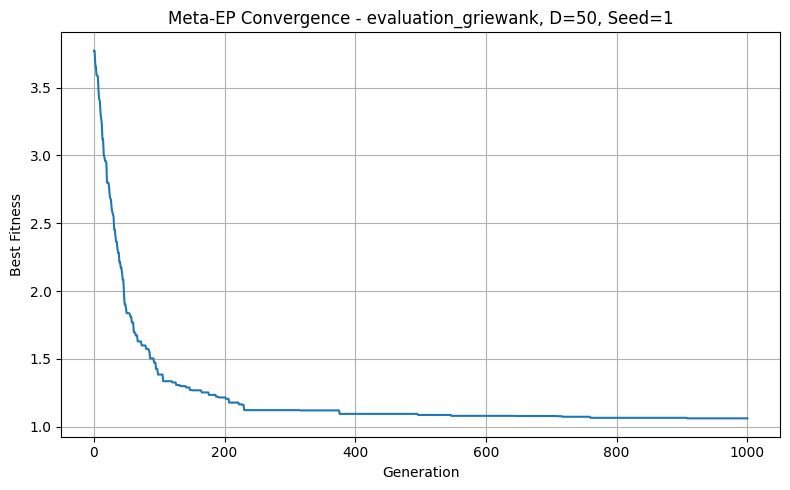

In [7]:
import matplotlib.pyplot as plt

# Note: Please change the number here if you want to see convergence curve for any generation other than 1
fitness_history = convergence_data[1]

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(fitness_history)),
    fitness_history
)

plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title(
    f"Meta-EP Convergence - "
    f"{EVALUATION_FUNC_NAME}, "
    f"D={NUM_DECISION_VARIABLES}, Seed=1"
)

plt.grid(True)
plt.tight_layout()

plt.show()